# Case Study 3 – Monetary Policy and Bank Lending, 2005–2023

Does the ECB policy rate (the main refinancing operations rate, MRO) move bank lending rates,
lending volumes, margins and credit risk across euro area countries?

- **Part A – Pass-through to lending rates.** Monthly lending rates by country for consumer
  credit, house purchase and corporations (ECB MFI interest rate statistics, public data).
- **Part B – Banks' balance sheets.** Loan growth, net interest margin, non-performing loans and
  loan loss reserves by country, from bank-level BankFocus data (licensed, not included in the
  repository; this notebook shows only country aggregates).

All models are panel regressions with **country fixed effects**: they use only the variation
over time within each country. Standard errors are reported in three versions: the usual ones,
clustered by country, and Driscoll-Kraay. The last section tests the assumptions behind the
models (country effects, serial correlation, cross-sectional dependence, Hausman test) and
explains why Driscoll-Kraay standard errors are the reference.

## Setup

In [1]:
suppressPackageStartupMessages({
  library(readxl)    # BankFocus Excel exports
  library(readr)     # CSV files
  library(dplyr)     # data manipulation (filter, mutate, joins, summarise)
  library(tidyr)     # fill() and pivot_longer()
  library(purrr)     # map over years, products and models
  library(stringr)   # country code from the ECB series names
  library(ggplot2)   # charts
  library(scales)    # axis formats
  library(plm)       # panel models, panel tests, Driscoll-Kraay standard errors
  library(lmtest)    # coeftest() with a robust covariance matrix
})

In [2]:
# Size of the charts shown in the notebook
options(repr.plot.width = 14, repr.plot.height = 7.5, repr.plot.res = 110)

In [3]:
DATA_DIR <- "data"      # public ECB CSV files (and, locally only, the BankFocus exports)
OUT_DIR  <- "output"    # tables and charts written by the script
YEARS    <- 2005:2023   # period of the analysis

# Year of euro adoption (1 January): a country enters the panels from that year
EURO_ADOPTION <- c(
  AT = 1999, BE = 1999, DE = 1999, ES = 1999, FI = 1999, FR = 1999, IE = 1999,
  IT = 1999, LU = 1999, NL = 1999, PT = 1999, GR = 2001, SI = 2007, CY = 2008,
  MT = 2008, SK = 2009, EE = 2011, LV = 2014, LT = 2015, HR = 2023
)

# BankFocus: one statement per bank and year by consolidation code (same rule as Case Study 1).
# A bank can appear with several statements; the first available code in this order is kept:
#   C1 consolidated, no unconsolidated companion  U1 unconsolidated, no consolidated companion
#   U2 unconsolidated, with a consolidated companion  C2 consolidated, with an unconsolidated one
#   C* / U* additional statements (e.g. a second accounting standard)
# NF (no financials) and LF (limited financials) are not in the list and are dropped.
CODE_PRIORITY <- c("C1", "U1", "U2", "C2", "C*", "U*")
# National central banks are in the BankFocus bank list but are not part of the banking sector
CENTRAL_BANKS <- c(
  "DEUTSCHE BUNDESBANK", "BANQUE DE FRANCE", "BANCA D'ITALIA", "BANCO DE ESPANA",
  "BANQUE CENTRALE DU LUXEMBOURG", "BANK OF GREECE", "BANCO DE PORTUGAL, EP",
  "CENTRAL BANK & FINANCIAL SERVICES AUTHORITY OF IRELAND",
  "SUOMEN PANKKI FINLANDS BANK", "NARODNA BANKA SLOVENSKA", "CENTRAL BANK OF CYPRUS",
  "LATVIJAS BANKA", "CENTRAL BANK OF MALTA", "NEDERLANDSCHE BANK NV (DE)"
)
# Short names for the columns of the BankFocus export, in the order of the export (amounts in
# EUR thousands, NIM and ratios in %). Only name, country, code, net_loans, npl,
# loan_loss_reserve and nim are used below.
BANKFOCUS_COLUMNS <- c(
  "row", "name", "country", "code", "total_assets", "net_loans", "npl",
  "mortgage_loans", "consumer_loans", "corporate_loans", "int_income_customers",
  "ecl_stage1", "ecl_stage2", "ecl_stage3", "ecl_total", "int_mortgage", "int_consumer",
  "int_corporate", "int_income_total", "loan_loss_reserve", "exp_loss", "loan_loss",
  "nii", "nim", "int_expense_total", "int_expense_deposits", "total_capital",
  "equity", "rwa"
)
# Statistical confidentiality (ECB rule for published statistics): no country value is shown
# if it rests on fewer than 3 banks
MIN_BANKS <- 3

# One BankFocus file per year (B2005.xlsx ... B2023.xlsx). They are licensed and not in the
# repository: Part B runs only if all of them are found, otherwise it is skipped.
BANKFOCUS_FILES <- file.path(DATA_DIR, paste0("B", YEARS, ".xlsx"))
BANKFOCUS_AVAILABLE <- all(file.exists(BANKFOCUS_FILES))
if (!BANKFOCUS_AVAILABLE) {
  message("BankFocus files not found in data/: they are licensed and not included in the ",
          "repository. Part A (public ECB data) runs; Part B is skipped. The executed notebook ",
          "shows all results.")
}

## ECB policy rates

The official rates change on specific dates; each rate is carried forward until its next change
and averaged over calendar days, so a rate in force for eleven months weighs eleven times more
than one in force for one month.

In [4]:
# read_ecb_csv(file)
# Reads an ECB Data Portal CSV and returns all columns as text, with DATE as a date.
# The files of this project were re-saved with each whole line in quotes
# ('"DATE,""TIME PERIOD"",...'); in that case the outer quotes are removed and the doubled
# quotes are turned back into single ones, so both that format and the standard one are read.
# A byte order mark at the start of the file, if any, is removed first.
read_ecb_csv <- function(file) {
  lines <- readLines(file.path(DATA_DIR, file), encoding = "UTF-8", warn = FALSE)
  lines <- sub("^\ufeff", "", lines)
  if (startsWith(lines[1], "\"DATE,")) {
    lines <- gsub("\"\"", "\"", substr(trimws(lines), 2, nchar(trimws(lines)) - 1))
  }
  df <- suppressWarnings(read_csv(I(paste(lines[lines != ""], collapse = "\n")),
                                  col_types = cols(.default = "c"), name_repair = "minimal"))
  mutate(df, DATE = as.Date(DATE))
}

# Daily policy rates. ECBrates.csv lists only the dates on which a rate changed; the three
# rates are found by their ECB series key (MRR_FR = MRO, DFR = deposit facility, MLFR =
# marginal lending facility), put on a complete daily calendar and carried forward until
# the next change.
daily_rates <- local({
  df <- read_ecb_csv("ECBrates.csv")
  # Column whose name contains the series key, e.g. "...(FM.B.U2.EUR.4F.KR.MRR_FR.LEV)"
  find <- function(key) as.numeric(df[[grep(paste0(".", key, "."), names(df), fixed = TRUE)[1]]])
  changes <- tibble(date = df$DATE, MRO = find("MRR_FR"), DFR = find("DFR"), MLF = find("MLFR"))
  days <- tibble(date = seq(min(changes$date), as.Date(paste0(max(YEARS), "-12-31")), by = "day"))
  full_join(changes, days, by = "date") %>%
    arrange(date) %>%
    fill(MRO, DFR, MLF, .direction = "down") %>%   # a rate stays in force until it changes
    semi_join(days, by = "date")                   # one row per calendar day
})
# Time-weighted averages: the mean over calendar days, by year and by month
yearly_rates <- daily_rates %>%
  group_by(year = as.integer(format(date, "%Y"))) %>%
  summarise(across(c(MRO, DFR, MLF), mean)) %>%
  filter(year %in% YEARS)
monthly_mro <- daily_rates %>%
  group_by(month = format(date, "%Y-%m")) %>%   # month as "2023-03", the key of Part A
  summarise(MRO = mean(MRO))

yearly_rates %>% mutate(across(-year, ~ round(.x, 2)))

year,MRO,DFR,MLF
<int>,<dbl>,<dbl>,<dbl>
2005,4.25,1.02,3.02
2006,4.25,1.76,3.76
2007,4.25,2.84,4.84
2008,4.03,3.01,4.78
2009,1.28,0.47,2.09
2010,1.00,0.25,1.75
2011,1.25,0.50,2.00
2012,0.88,0.13,1.63
2013,0.55,0.00,1.14


In [5]:
# policy_rates_chart(): daily DFR, MLF and MRO since 2005 (step lines)
policy_rates_chart <- function() {
  daily_rates %>%
    filter(date >= as.Date("2005-01-01")) %>%
    pivot_longer(c(DFR, MLF, MRO), names_to = "RateType", values_to = "Value") %>%
    ggplot(aes(date, Value, colour = RateType)) +
    geom_line(linewidth = 1) +
    scale_x_date(date_breaks = "1 year", date_labels = "%Y") +
    labs(title = "ECB Policy Rates Since 2005", x = "Date", y = "Interest Rate in %",
         colour = "RateType") +
    theme_minimal()
}

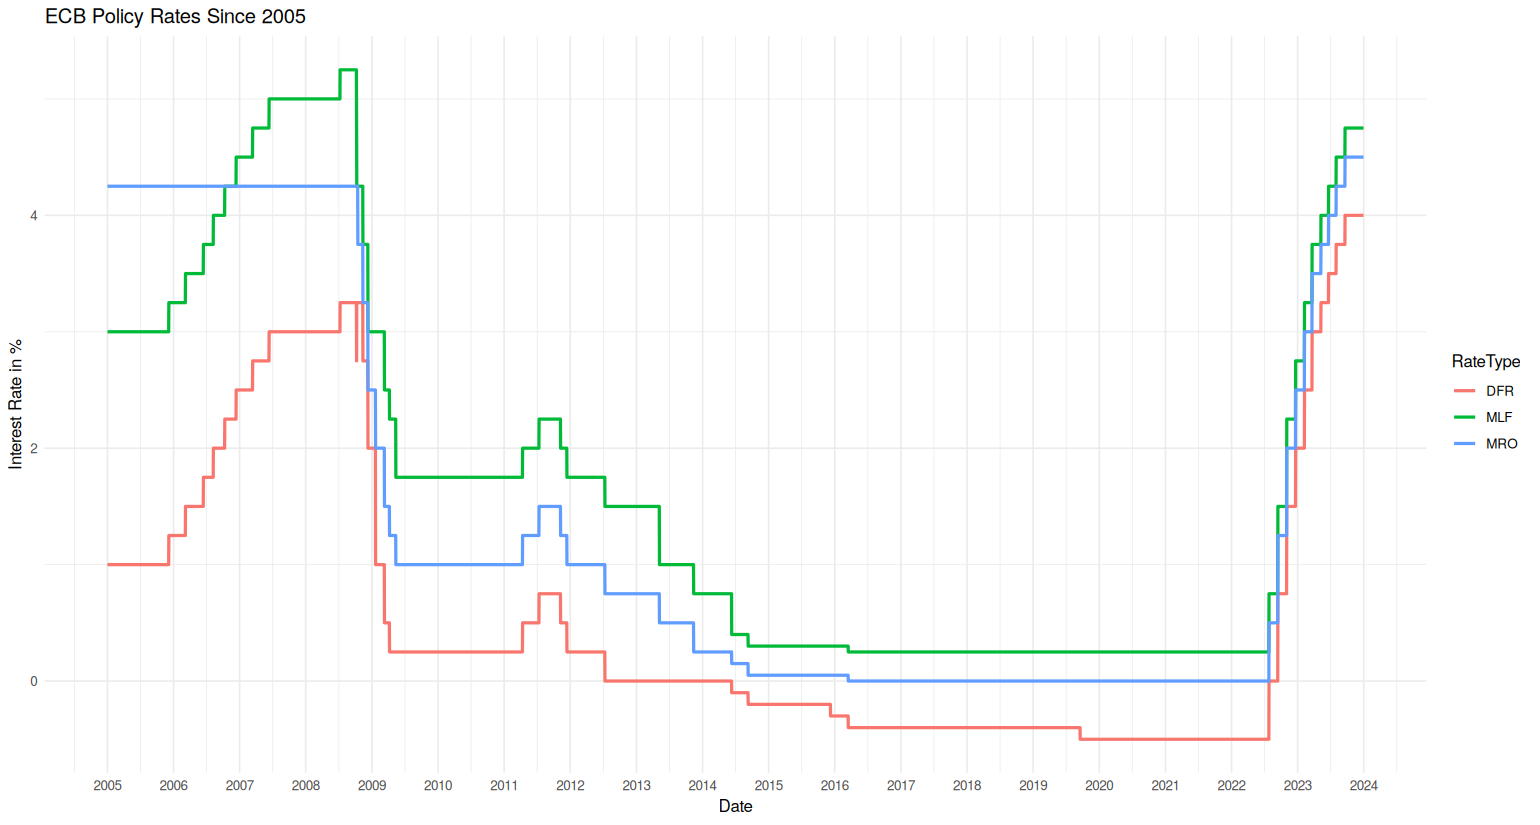

In [6]:
policy_rates_chart()

## Part A – Pass-through to lending rates

Monthly lending rates by country (ECB MFI interest rate statistics): consumer credit, loans for
house purchase and loans to corporations. A country enters the panel from the year it adopted
the euro. The monthly MRO is the average over the days of the month.

In [7]:
# One file per product; each file has one column per country
LENDING_RATE_FILES <- c(Consumption = "Consumption.csv", Mortgages = "HousePurchase.csv",
                        Corporations = "Corporations.csv")

# Long panel with one row per product, country and month: product, country, month, rate and
# the monthly MRO. The country code is read from the ECB series key in the column name,
# e.g. "Bank interest rates - ... (MIR.M.IT.B.A2B...)" -> "IT".
rate_panel <- imap_dfr(LENDING_RATE_FILES, function(file, product) {
  df <- read_ecb_csv(file)
  # Value columns: one per country (the other columns are DATE and TIME PERIOD)
  value_cols <- names(df)[startsWith(names(df), "Bank interest") | startsWith(names(df), "Cost of")]
  df %>%
    select(DATE, all_of(value_cols)) %>%
    pivot_longer(-DATE, names_to = "series", values_to = "rate") %>%   # wide -> long
    transmute(month = format(DATE, "%Y-%m"),
              country = str_match(series, "\\(MIR\\.M\\.([A-Z]{2})\\.")[, 2],
              product = product,
              rate = suppressWarnings(as.numeric(rate)))
}) %>%
  filter(!is.na(rate), as.integer(substr(month, 1, 4)) %in% YEARS) %>%
  filter(unname(EURO_ADOPTION[country]) <= as.integer(substr(month, 1, 4))) %>%  # euro members
  left_join(monthly_mro, by = "month") %>%        # MRO of the same month, matched by key
  mutate(date = as.Date(paste0(month, "-01")))    # date version of the month, for the charts

# Size of each panel
rate_panel %>% group_by(product) %>%
  summarise(countries = n_distinct(country), observations = n(), .groups = "drop")

product,countries,observations
<chr>,<int>,<int>
Consumption,18,3558
Corporations,19,3888
Mortgages,19,3888


In [8]:
# model_spec(data, formula, index, label, dk_lags)
# Everything needed to estimate one model, kept together so that the same list of models can
# be passed to the regression table and to the diagnostic tests:
#   data     panel data (one row per country and period)
#   formula  e.g. rate ~ MRO
#   index    panel identifiers: c("country", "month") or c("country", "year")
#   label    name of the model in the tables
#   dk_lags  lags allowed in the Driscoll-Kraay standard errors: 12 for the monthly panels
#            (one year), 2 for the yearly ones
model_spec <- function(data, formula, index, label, dk_lags) {
  list(data = data, formula = formula, index = index, label = label, dk_lags = dk_lags)
}

# fe_model(spec): country fixed-effects ("within") estimator. Each variable is demeaned by
# country, so the coefficient uses only the variation over time within each country.
fe_model <- function(spec) {
  plm(spec$formula, data = pdata.frame(spec$data, index = spec$index), model = "within")
}

# fe_regression(spec)
# Estimates the fixed-effects model and returns one table row with the MRO coefficient and
# three sets of standard errors and p-values:
#   usual           assume independent residuals (too small here, see the diagnostic tests)
#   clustered       by country (Arellano): robust to autocorrelation within a country
#   Driscoll-Kraay  robust to autocorrelation AND to correlation across countries in the
#                   same period (common shocks); the reference in the README
# plus the within R-squared, the number of countries and the number of observations.
fe_regression <- function(spec) {
  m <- fe_model(spec)
  usual <- summary(m)$coefficients["MRO", ]   # estimate, std. error, t value, p-value
  clustered <- coeftest(m, vcov = vcovHC(m, method = "arellano", cluster = "group"))["MRO", ]
  dk <- coeftest(m, vcov = vcovSCC(m, maxlag = spec$dk_lags))["MRO", ]
  tibble(model = spec$label, MRO_coefficient = usual[["Estimate"]],
         std_error = usual[["Std. Error"]], p_value = usual[["Pr(>|t|)"]],
         std_error_clustered = clustered[["Std. Error"]],
         p_value_clustered = clustered[["Pr(>|t|)"]],
         std_error_dk = dk[["Std. Error"]], p_value_dk = dk[["Pr(>|t|)"]],
         r2_within = summary(m)$r.squared[["rsq"]],
         countries = pdim(m)$nT$n, observations = nobs(m))
}

# Pass-through: one model per product, lending rate on the monthly MRO
rate_specs <- map(names(LENDING_RATE_FILES), function(p) {
  model_spec(filter(rate_panel, product == p), rate ~ MRO, c("country", "month"),
             paste("Lending rate,", p), dk_lags = 12)
})
pass_through <- map_dfr(rate_specs, fe_regression)
pass_through %>% mutate(across(where(is.double), ~ signif(.x, 3)))

model,MRO_coefficient,std_error,p_value,std_error_clustered,p_value_clustered,std_error_dk,p_value_dk,r2_within,countries,observations
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
"Lending rate, Consumption",0.306,0.01370,7.42e-104,0.0679,6.85e-06,0.0663,4.16e-06,0.124,18,3558
"Lending rate, Mortgages",0.569,0.00738,0.00e+00,0.0338,2.21e-61,0.0723,4.43e-15,0.606,19,3888
"Lending rate, Corporations",0.659,0.00724,0.00e+00,0.0256,8.82e-135,0.0728,2.20e-19,0.682,19,3888


In [9]:
# Lending rates by country and product, one panel per country
lending_rates_by_country_chart <- function() {
  ggplot(rate_panel, aes(date, rate, colour = product)) +
    geom_line() +
    facet_wrap(~ country) +
    labs(title = "Bank Interest Rates Since 2005", x = "Date", y = "Interest Rate in %",
         colour = "RateType") +
    theme_minimal()
}

# One product, all countries in one chart, one colour per country
lending_rate_chart <- function(p, title) {
  ggplot(filter(rate_panel, product == p), aes(date, rate, colour = country)) +
    geom_point(size = 0.8) +
    scale_colour_viridis_d(option = "turbo") +
    labs(title = title, x = "Date", y = "%", colour = "Country") +
    theme_minimal()
}

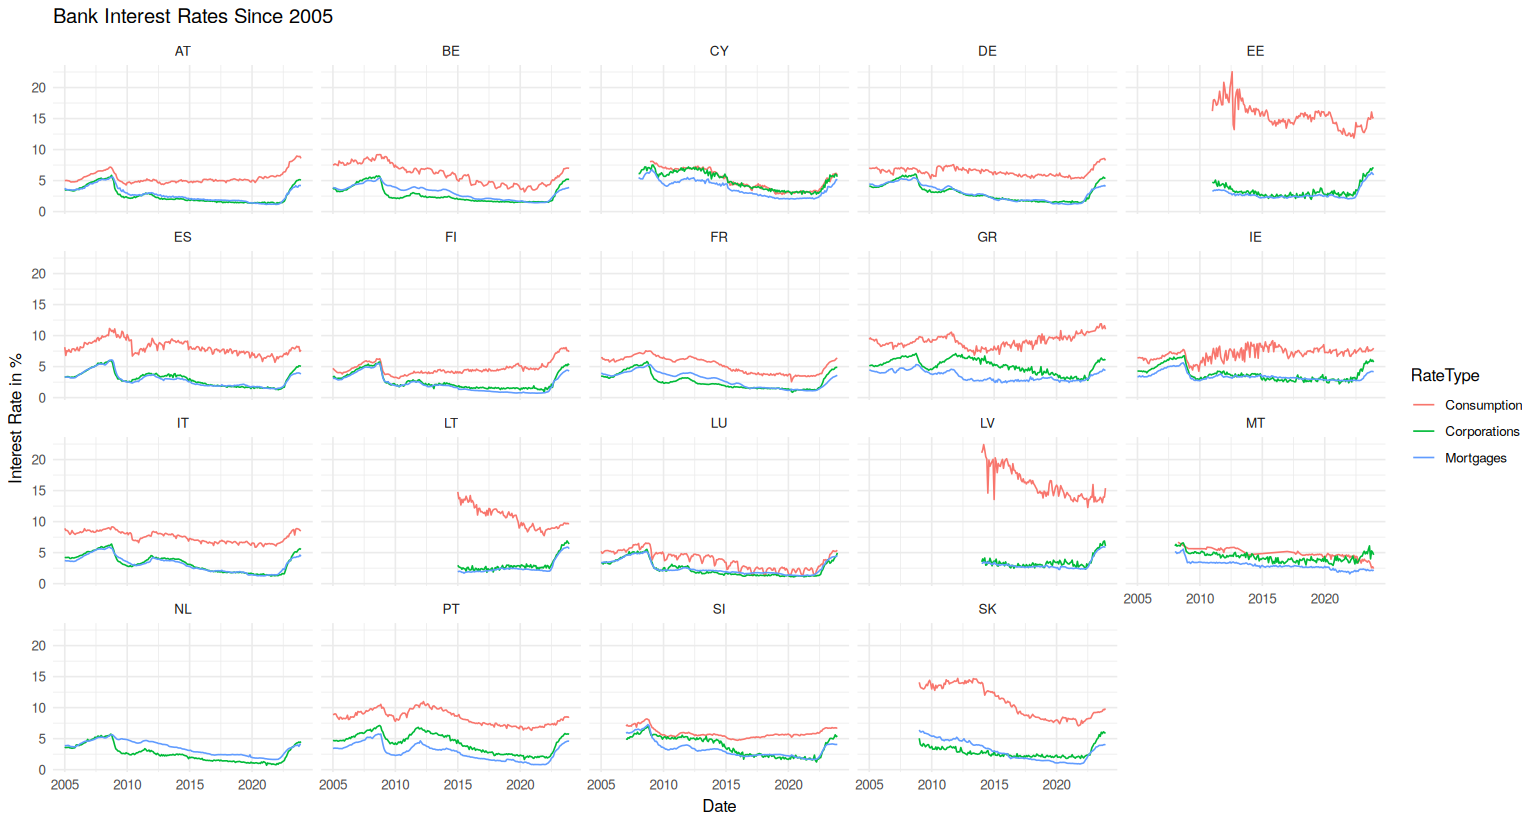

In [10]:
lending_rates_by_country_chart()

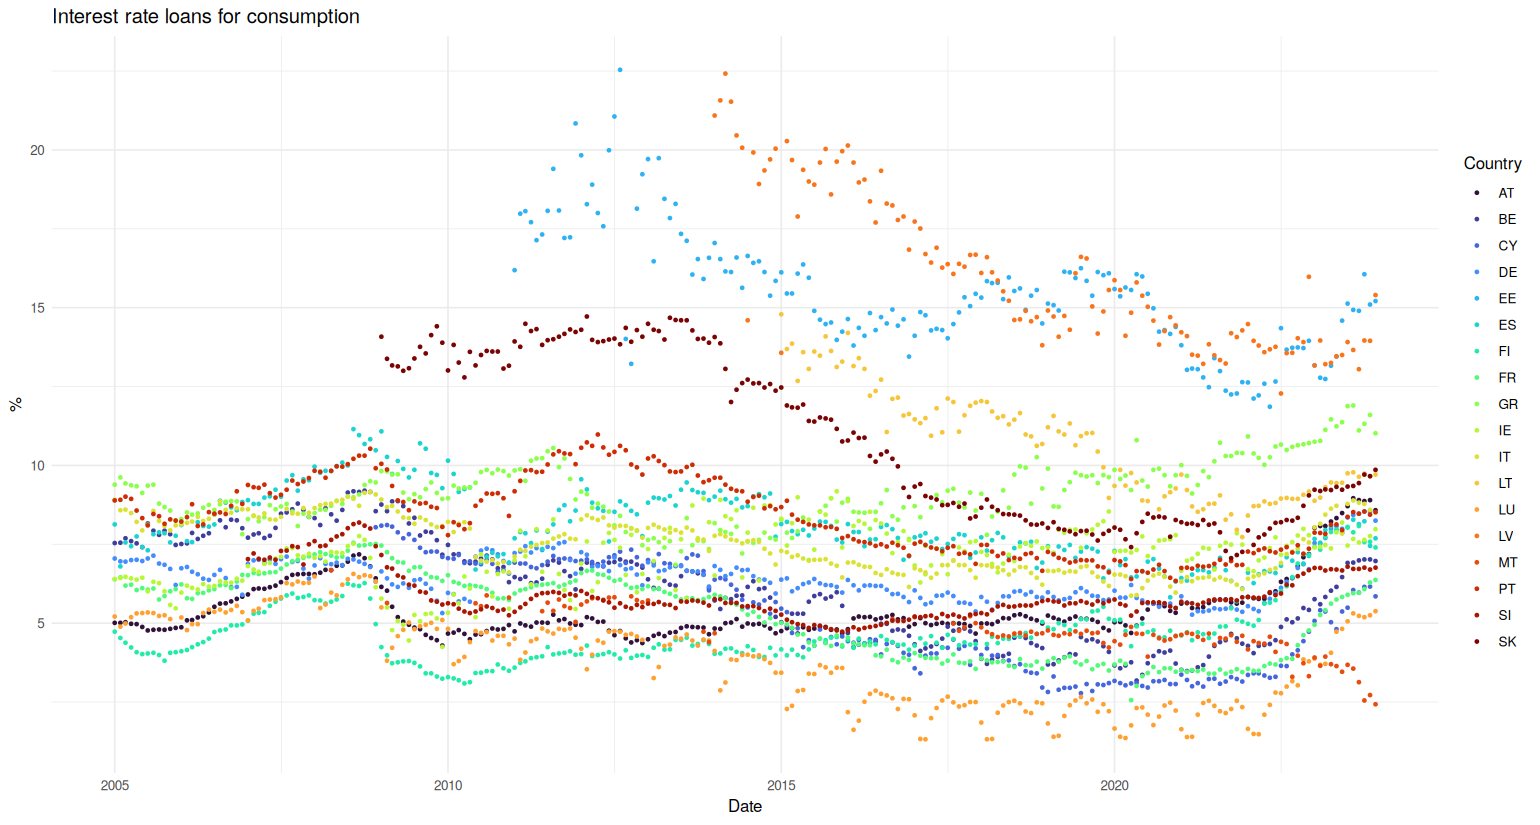

In [11]:
lending_rate_chart("Consumption", "Interest rate loans for consumption")

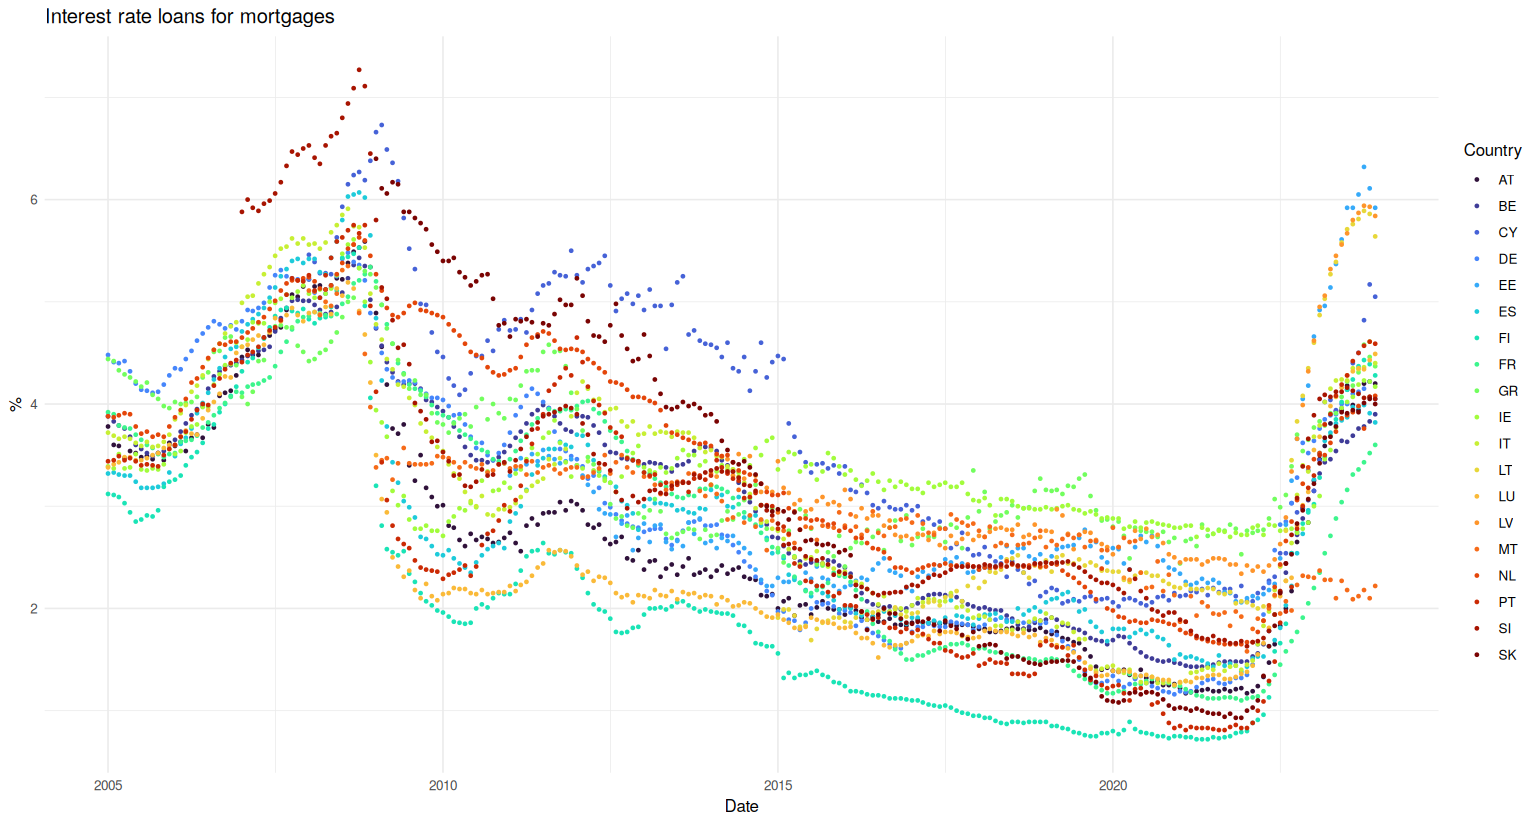

In [12]:
lending_rate_chart("Mortgages", "Interest rate loans for mortgages")

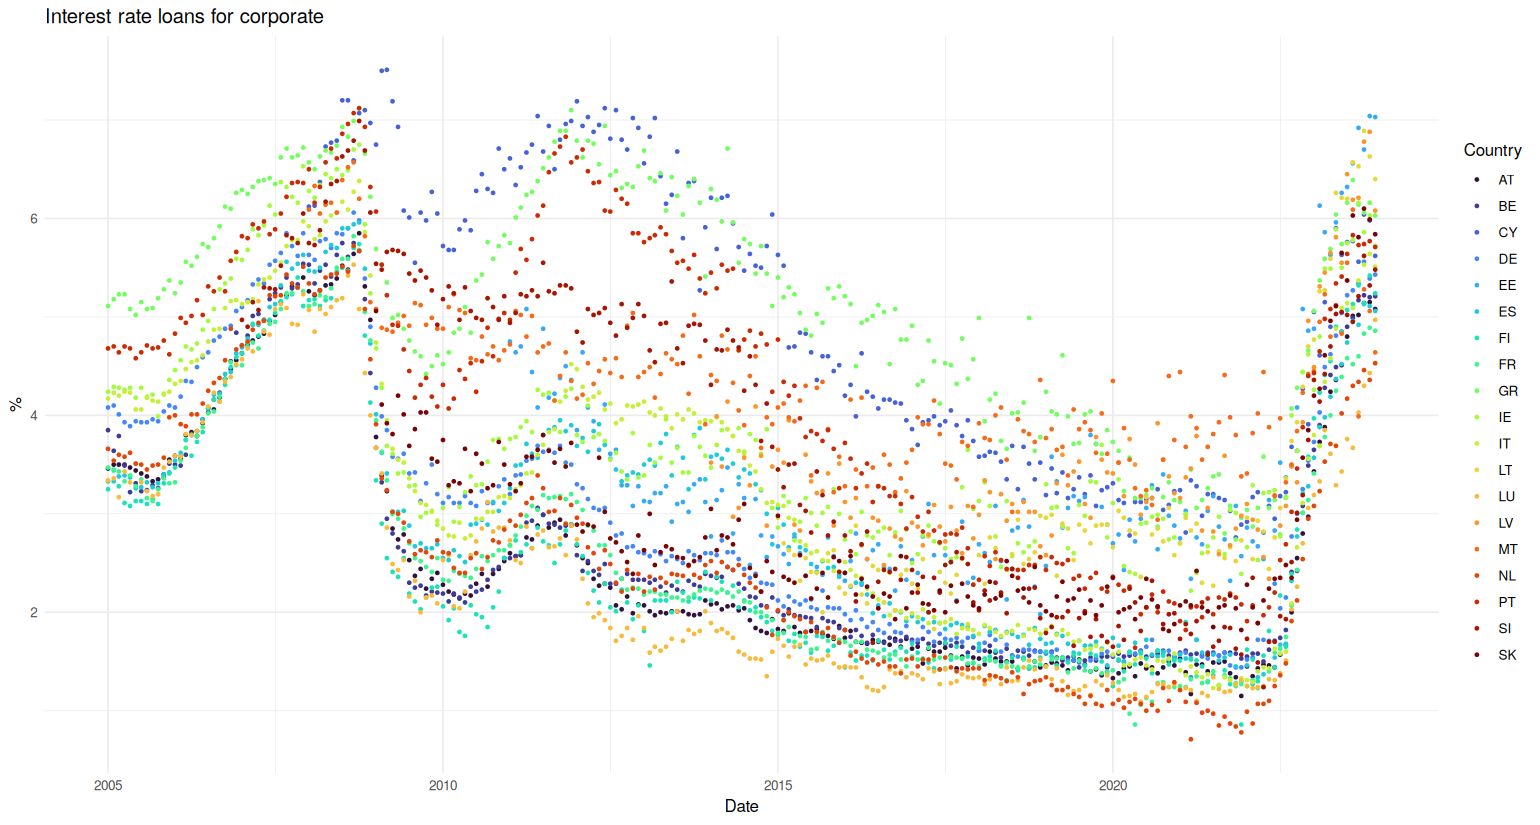

In [13]:
lending_rate_chart("Corporations", "Interest rate loans for corporate")

## Part B – Banks' balance sheets (BankFocus)

BankFocus coverage changes a lot over 2005–2023: the number of banks with loan data doubles,
and German banks alone go from 938 in 2012 to 1,855 in 2013. Summing loans over whatever banks
are available would mix credit growth with banks entering the database. Three rules keep the
comparisons clean:

1. **Loan growth on matched banks.** Growth in year t is computed only on banks that report
   loans in both t and t−1, as the ECB does for growth rates: sum(loans_t) / sum(loans_t−1) − 1.
2. **Balanced samples for ratios.** The net interest margin uses banks that report it in every
   year since 2005 (or since the country joined the euro). NPL and loan loss reserves are
   reported by few banks before 2013, so they use banks that report them every year from 2013.
3. **At least 3 banks** behind every country value.

In [14]:
# load_bankfocus()
# Reads the 19 yearly exports and stacks them into one bank-level table (one row per
# statement and year). Always the "Results" sheet: some files also have a "Search summary"
# sheet. "n.a." becomes NA. Then keeps only banks of euro members in that year, removes the
# national central banks and the statements without financials.
load_bankfocus <- function() {
  map_dfr(YEARS, function(year) {
    df <- read_excel(file.path(DATA_DIR, paste0("B", year, ".xlsx")), sheet = "Results",
                     na = "n.a.", .name_repair = "unique_quiet")
    df <- df[, seq_along(BANKFOCUS_COLUMNS)]   # the 29 columns of the export
    names(df) <- BANKFOCUS_COLUMNS
    df %>% select(-row) %>% mutate(year = year)   # row number of the export is not needed
  }) %>%
    filter(unname(EURO_ADOPTION[country]) <= year,   # euro members only
           !name %in% CENTRAL_BANKS,
           code %in% CODE_PRIORITY)                  # drops NF / LF (no financials)
}

# one_statement_per_bank(df, vars)
# Keeps one statement per bank and year. First drops the statements where any of `vars` is
# missing, then, among those left, keeps the one with the best consolidation code according
# to CODE_PRIORITY. A bank is identified by name AND country, since different banks in
# different countries can have the same name.
one_statement_per_bank <- function(df, vars) {
  df %>%
    filter(if_all(all_of(vars), ~ !is.na(.x))) %>%   # the variables needed are all reported
    mutate(rank = match(code, CODE_PRIORITY)) %>%    # 1 = C1, 2 = U1, ...
    arrange(rank) %>%
    distinct(name, country, year, .keep_all = TRUE) %>%   # first row = best code
    select(-rank)
}

# balanced_sample(df, start)
# Keeps only the banks observed in every year from `start` to 2023. For countries that
# adopted the euro after `start` the sample starts at the adoption year instead
# (e.g. Lithuania from 2015). With a fixed set of banks, changes over time reflect the
# banks themselves and not banks entering or leaving the database.
balanced_sample <- function(df, start) {
  df %>%
    filter(year >= start) %>%
    mutate(first = pmax(start, unname(EURO_ADOPTION[country]))) %>%   # first required year
    group_by(name, country) %>%
    filter(n_distinct(year) == max(YEARS) - first[1] + 1) %>%   # present in all those years
    ungroup() %>%
    select(-first)
}

# confidential(df)
# Statistical confidentiality: removes the country-year values that rest on fewer than
# MIN_BANKS banks. Applied to every country aggregate before it is shown or saved.
confidential <- function(df) filter(df, n_banks >= MIN_BANKS)

In [15]:
if (BANKFOCUS_AVAILABLE) {
  banks <- load_bankfocus()   # bank-level table, all years (never shown or saved)

  # 1. Loan growth on banks reporting loans in both t and t-1.
  # The loans table is joined with itself shifted by one year: a bank's loans in year t-1 are
  # relabelled as year t, so the inner join keeps exactly the banks present in both years.
  # Growth of the country = sum(loans_t) / sum(loans_t-1) - 1 over those banks, in %.
  loans <- one_statement_per_bank(banks, "net_loans") %>% select(name, country, year, net_loans)
  loan_growth <- inner_join(loans, mutate(loans, year = year + 1L),
                            by = c("name", "country", "year"), suffix = c("", "_prev")) %>%
    group_by(country, year) %>%
    summarise(loan_growth = 100 * (sum(net_loans) / sum(net_loans_prev) - 1),
              n_banks = n(), .groups = "drop") %>%
    confidential() %>%
    left_join(yearly_rates, by = "year")   # yearly MRO, DFR and MLF

  # Loan stocks on the balanced sample, EUR bn (from EUR thousands), for the chart of loans
  # over time only: not used in the regressions
  loan_stock <- balanced_sample(loans, 2005) %>%
    group_by(country, year) %>%
    summarise(net_loans_bn = sum(net_loans) / 1e6, n_banks = n(), .groups = "drop") %>%
    confidential()

  # 2. Net interest margin of the median bank in each country and year, balanced sample
  # since 2005. The median is used because the NIM is a ratio: it cannot be summed, and the
  # median is not driven by a few banks with extreme margins.
  nim <- one_statement_per_bank(banks, "nim") %>%
    balanced_sample(2005) %>%
    group_by(country, year) %>%
    summarise(nim = median(nim), n_banks = n(), .groups = "drop") %>%
    confidential() %>%
    left_join(yearly_rates, by = "year")

  # 3. NPL ratio and loan loss reserves over net loans, balanced sample since 2013, %.
  # Ratios of country totals (sum of NPL / sum of net loans), so large banks weigh more,
  # as in aggregate banking statistics.
  credit_risk <- one_statement_per_bank(banks, c("net_loans", "npl", "loan_loss_reserve")) %>%
    balanced_sample(2013) %>%
    group_by(country, year) %>%
    summarise(npl_ratio = 100 * sum(npl) / sum(net_loans),
              llr_ratio = 100 * sum(loan_loss_reserve) / sum(net_loans),
              n_banks = n(), .groups = "drop") %>%
    confidential() %>%
    left_join(yearly_rates, by = "year")

  # Size of each panel: countries and country-year observations after all the filters
  tibble(panel = c("loan growth (matched banks)", "loan stock (balanced 2005-2023)",
                   "NIM (balanced 2005-2023)", "NPL and reserves (balanced 2013-2023)"),
         countries = c(n_distinct(loan_growth$country), n_distinct(loan_stock$country),
                       n_distinct(nim$country), n_distinct(credit_risk$country)),
         country_years = c(nrow(loan_growth), nrow(loan_stock), nrow(nim), nrow(credit_risk)))
}

panel,countries,country_years
<chr>,<int>,<int>
loan growth (matched banks),19,305
loan stock (balanced 2005-2023),19,309
NIM (balanced 2005-2023),19,309
NPL and reserves (balanced 2013-2023),20,207


### Loans

In [16]:
# loans_by_country_chart(): net loans over time, one panel per country (countries with more
# than one year), each panel on its own scale
loans_by_country_chart <- function() {
  ggplot(add_count(loan_stock, country) %>% filter(n > 1), aes(year, net_loans_bn)) +
    geom_line(colour = "blue") + geom_point(colour = "blue", size = 1) +
    facet_wrap(~ country, scales = "free_y") +
    labs(title = "Net loans by country, balanced sample of banks (EUR bn)",
         x = "Year", y = NULL) +
    theme_minimal()
}

# loan_growth_chart(): each point is one country and year, loan growth against the yearly MRO
loan_growth_chart <- function() {
  ggplot(loan_growth, aes(MRO, loan_growth, colour = country)) +
    geom_point(size = 3) +
    scale_colour_viridis_d(option = "turbo") +
    labs(title = "Loan growth and the Main Refinancing Operations rate",
         x = "MRO, yearly average (%)", y = "Loan growth, matched banks (%)",
         colour = "Country") +
    theme_minimal()
}

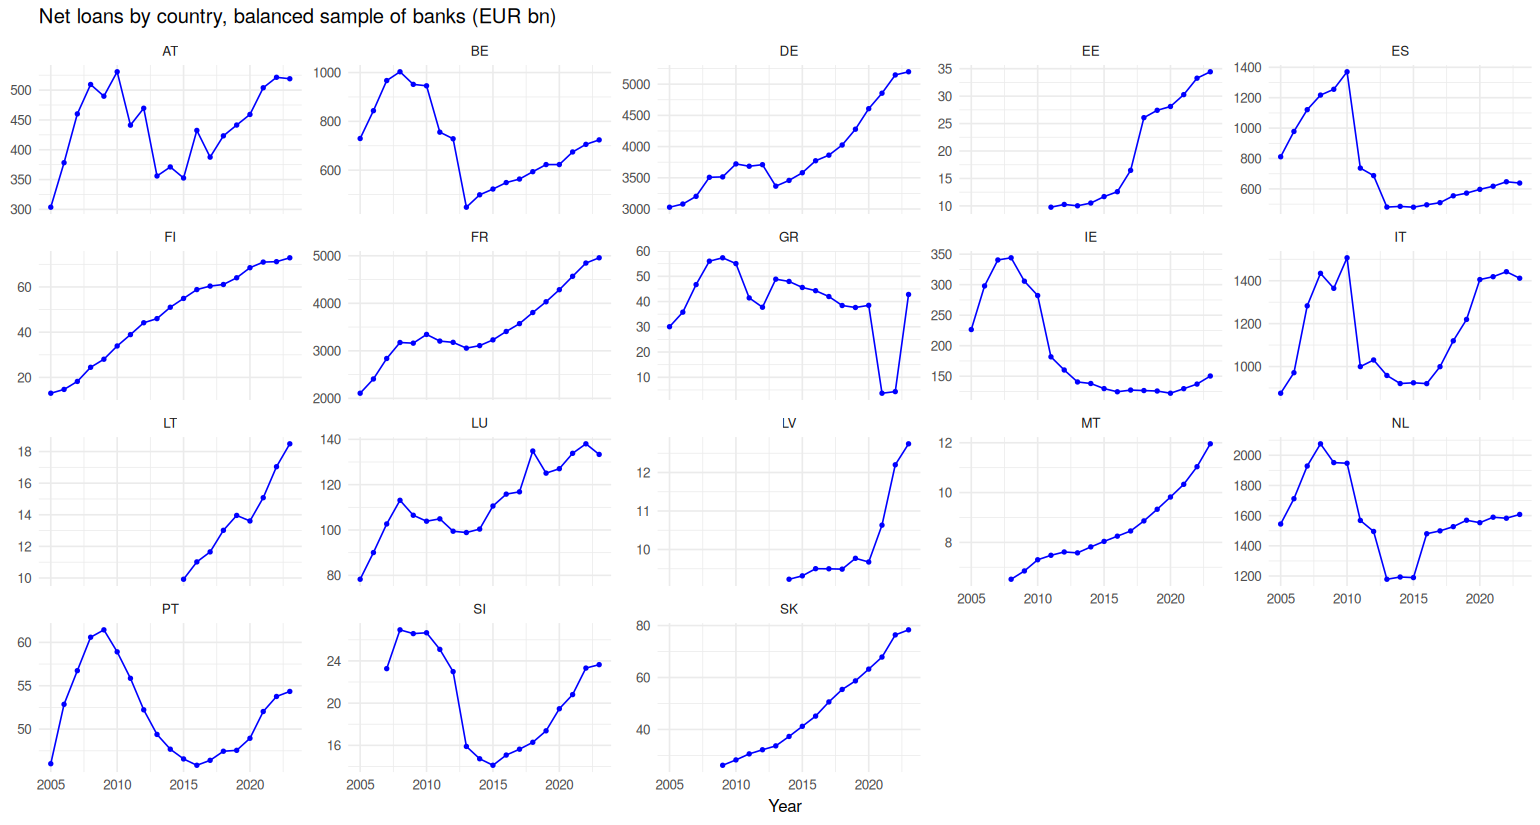

In [17]:
if (BANKFOCUS_AVAILABLE) loans_by_country_chart()

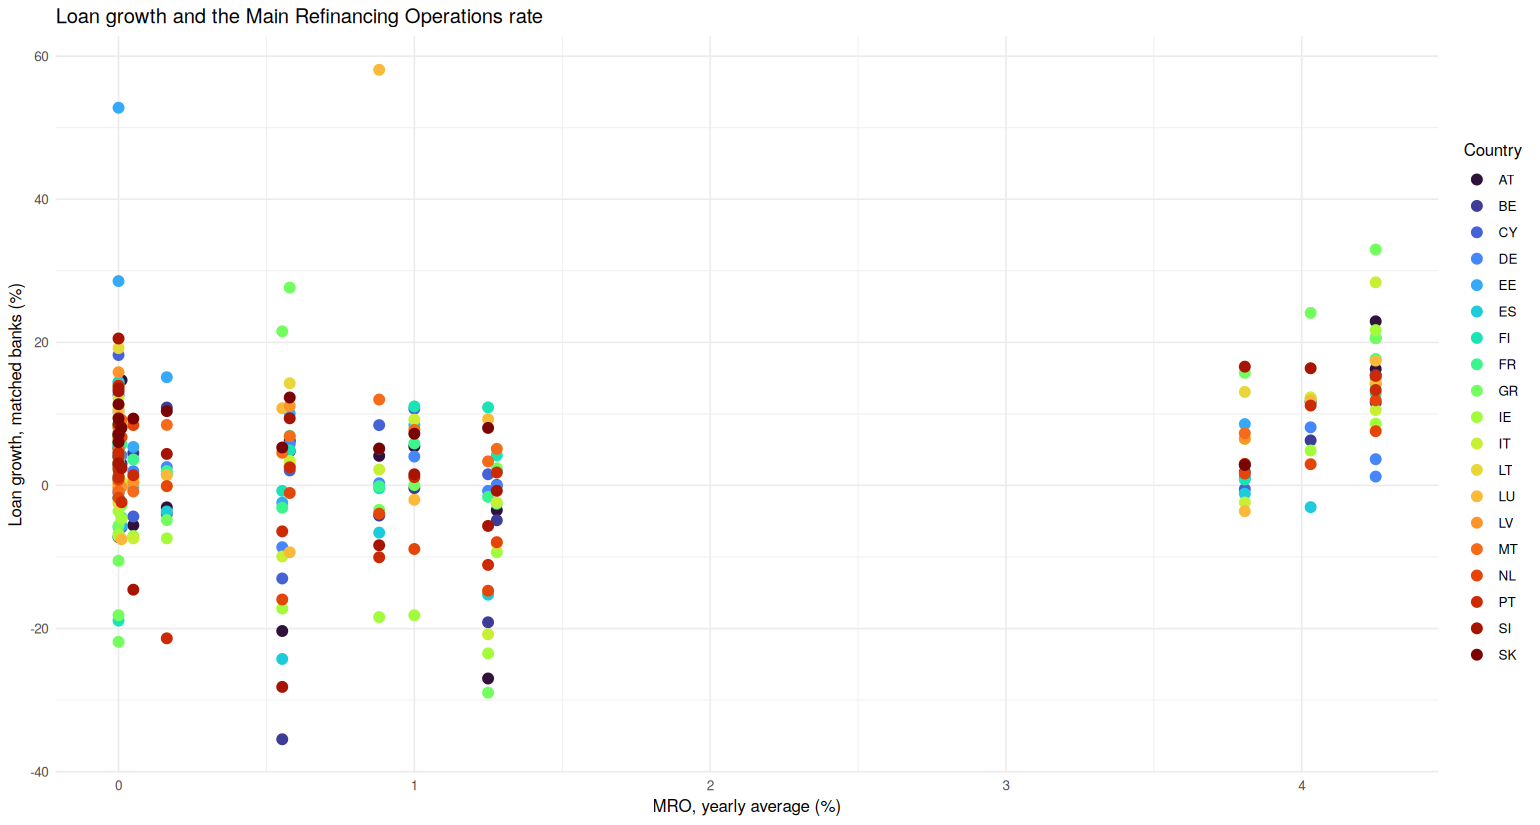

In [18]:
if (BANKFOCUS_AVAILABLE) loan_growth_chart()

### Net interest margin

In [19]:
# means_chart(df, value, by, title, ylab)
# Mean of `value` for each group of `by` (country or year) with a 95% confidence interval,
# mean +/- 1.96 standard errors: the same chart as gplots::plotmeans in the original study.
means_chart <- function(df, value, by, title, ylab) {
  df %>%
    group_by(group = factor(.data[[by]])) %>%
    summarise(mean = mean(.data[[value]]), se = sd(.data[[value]]) / sqrt(n()),
              .groups = "drop") %>%
    filter(!is.na(se)) %>%   # groups with a single observation have no interval
    ggplot(aes(group, mean, group = 1)) +
    geom_line(colour = "grey40") +
    geom_pointrange(aes(ymin = mean - 1.96 * se, ymax = mean + 1.96 * se), colour = "blue") +
    labs(title = title, x = NULL, y = ylab) +
    theme_minimal()
}

# nim_fe_chart()
# One panel per country: the NIM against the MRO, and the fitted line of the fixed-effects
# model for that country (its own intercept, fixef(), and the common MRO slope). Each
# country's line is drawn only in its own panel.
nim_fe_chart <- function() {
  m <- plm(nim ~ MRO, data = pdata.frame(nim, index = c("country", "year")), model = "within")
  d <- add_count(nim, country) %>% filter(n > 1)   # countries with more than one year
  lines <- tibble(country = names(fixef(m)), intercept = as.numeric(fixef(m)),
                  slope = coef(m)[["MRO"]]) %>%
    filter(country %in% d$country)
  ggplot(d, aes(MRO, nim)) +
    geom_point(colour = "blue") +
    geom_abline(data = lines, aes(intercept = intercept, slope = slope), colour = "firebrick") +
    facet_wrap(~ country, scales = "free_y") +
    labs(title = "Net interest margin and the MRO, with the country fixed-effects fit",
         x = "MRO, yearly average (%)", y = "NIM, median bank (%)") +
    theme_minimal()
}

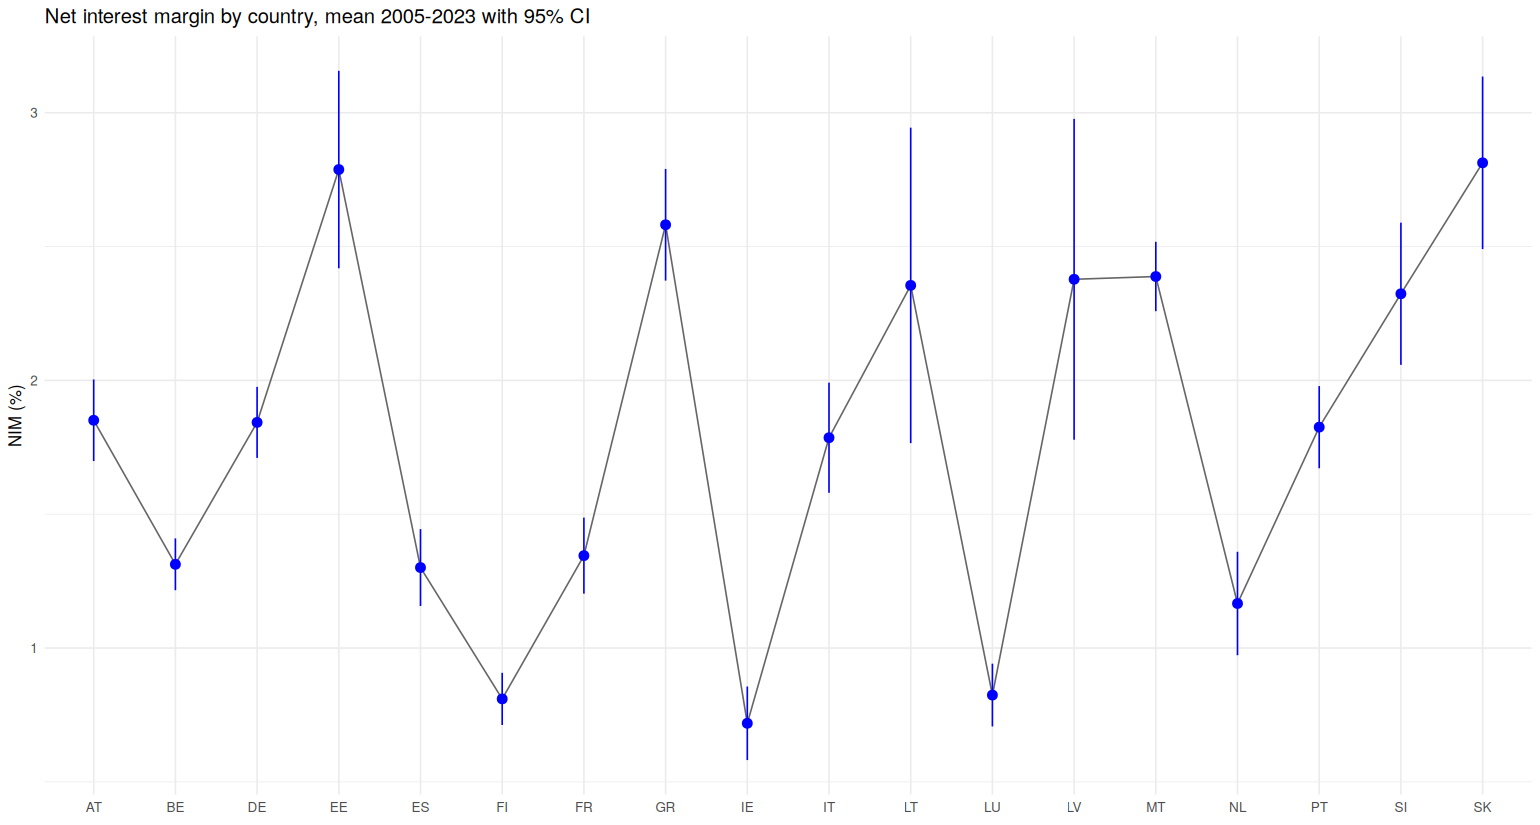

In [20]:
if (BANKFOCUS_AVAILABLE) means_chart(nim, "nim", "country", "Net interest margin by country, mean 2005-2023 with 95% CI", "NIM (%)")

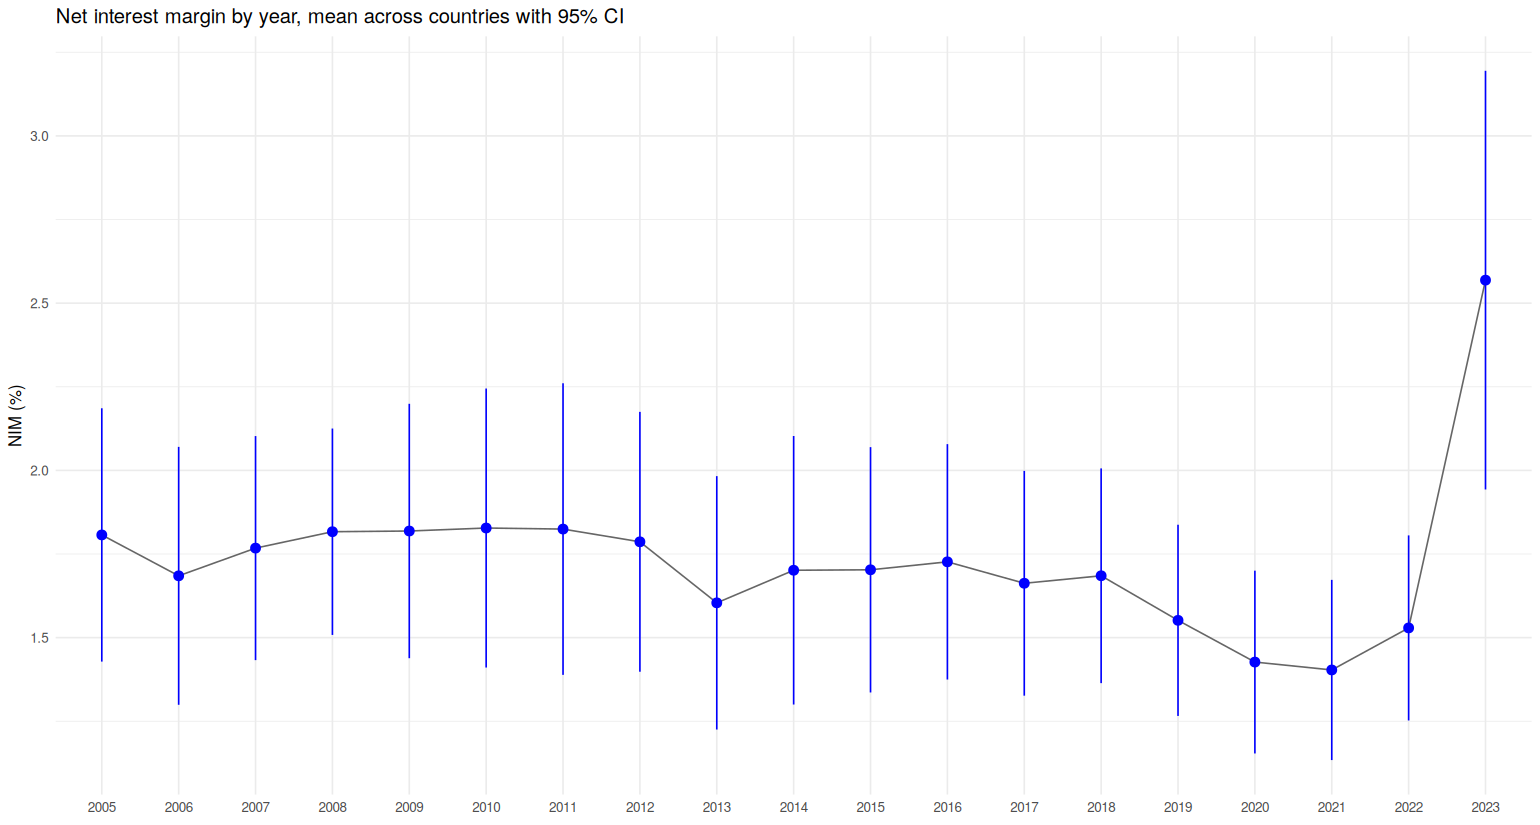

In [21]:
if (BANKFOCUS_AVAILABLE) means_chart(nim, "nim", "year", "Net interest margin by year, mean across countries with 95% CI", "NIM (%)")

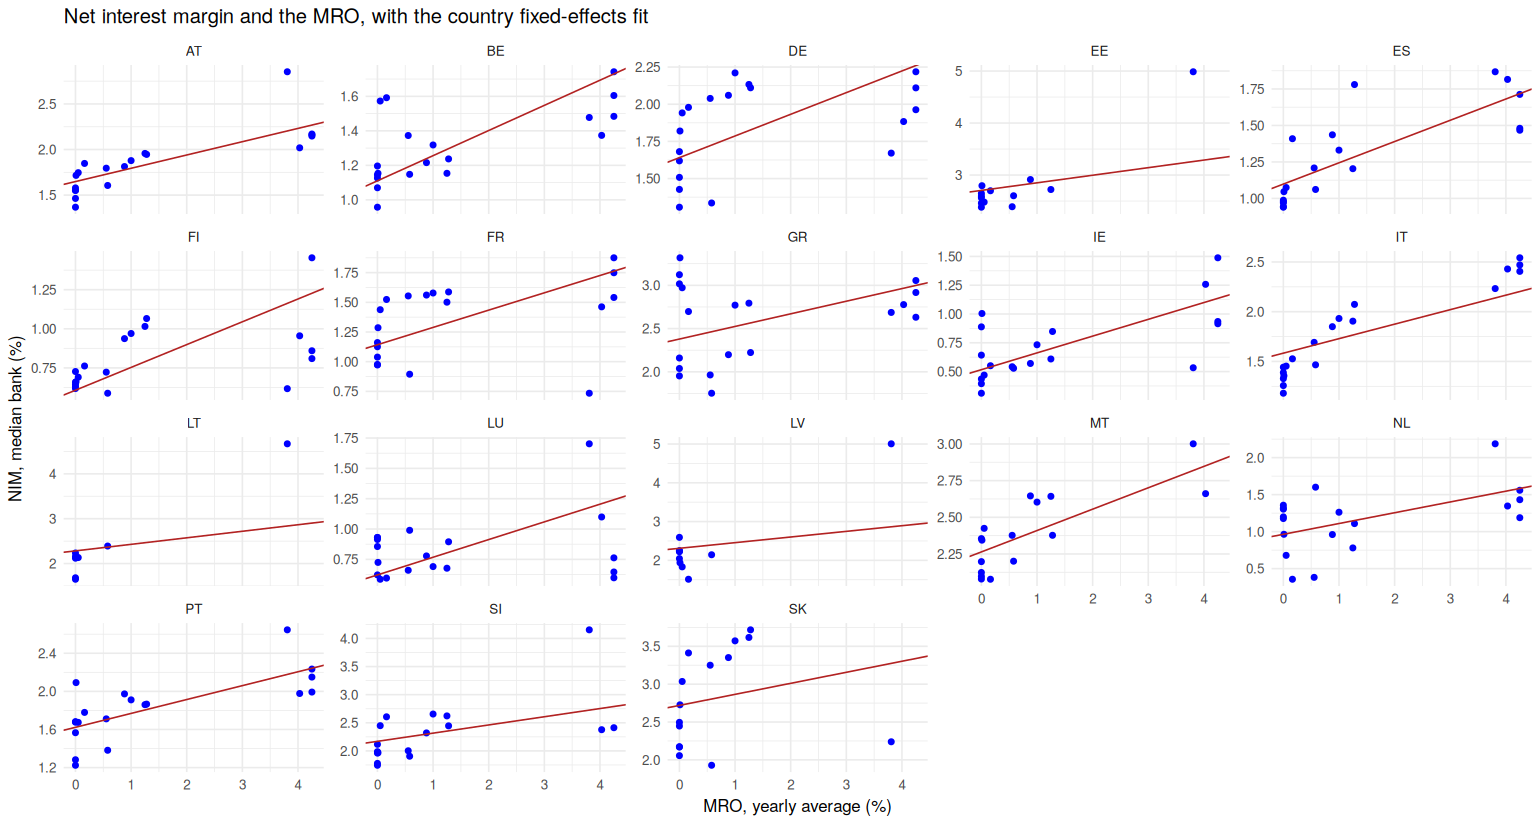

In [22]:
if (BANKFOCUS_AVAILABLE) nim_fe_chart()

### Credit risk: non-performing loans and loan loss reserves

In [23]:
# credit_risk_chart(value, title, ylab): NPL or reserves ratio against the yearly MRO,
# one point per country and year
credit_risk_chart <- function(value, title, ylab) {
  ggplot(credit_risk, aes(MRO, .data[[value]], colour = country)) +
    geom_point(size = 3) +
    scale_colour_viridis_d(option = "turbo") +
    labs(title = title, x = "MRO, yearly average (%)", y = ylab, colour = "Country") +
    theme_minimal()
}

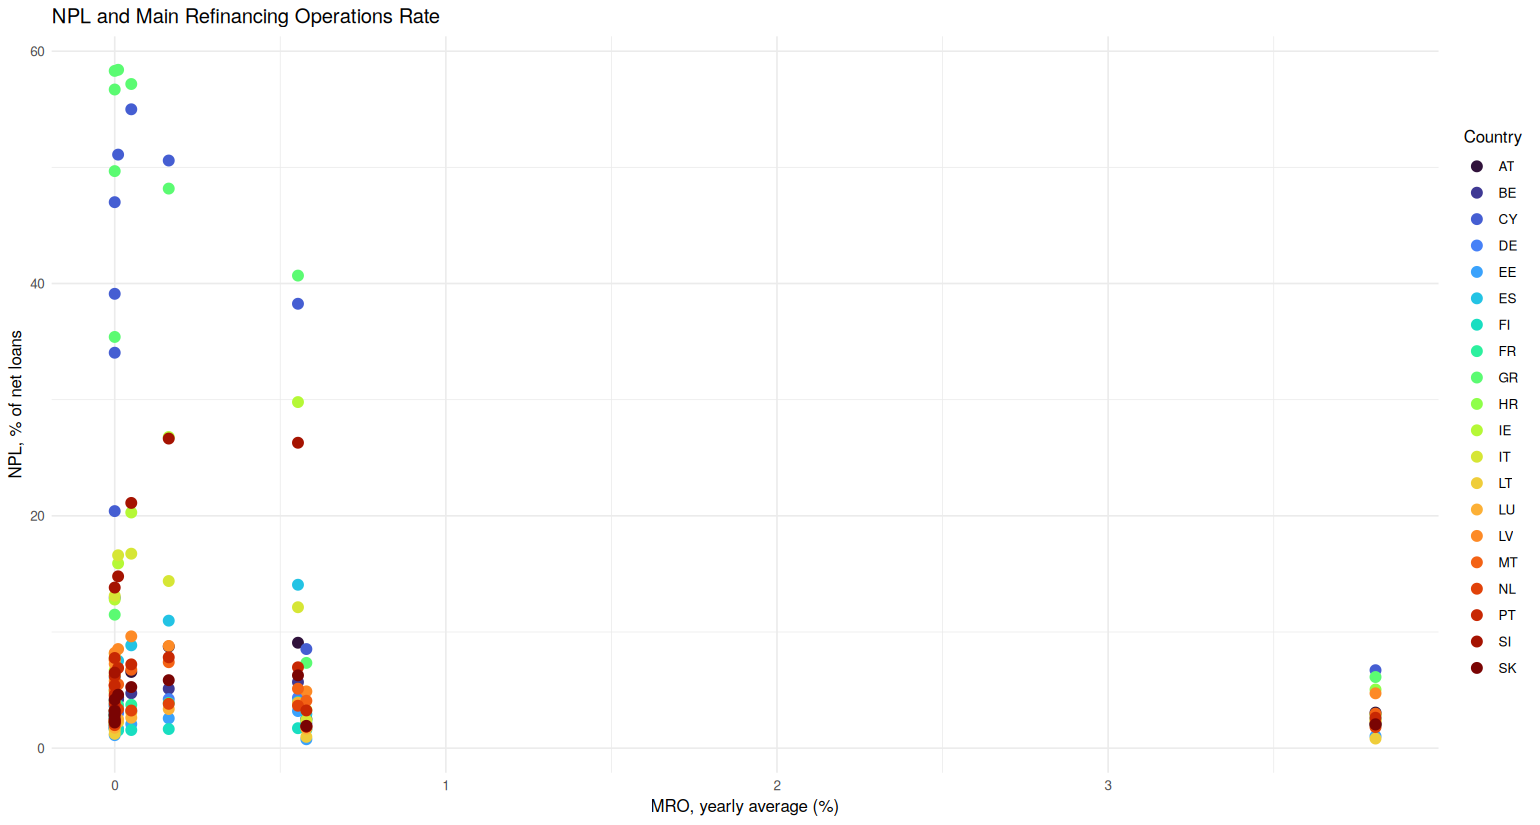

In [24]:
if (BANKFOCUS_AVAILABLE) credit_risk_chart("npl_ratio", "NPL and Main Refinancing Operations Rate", "NPL, % of net loans")

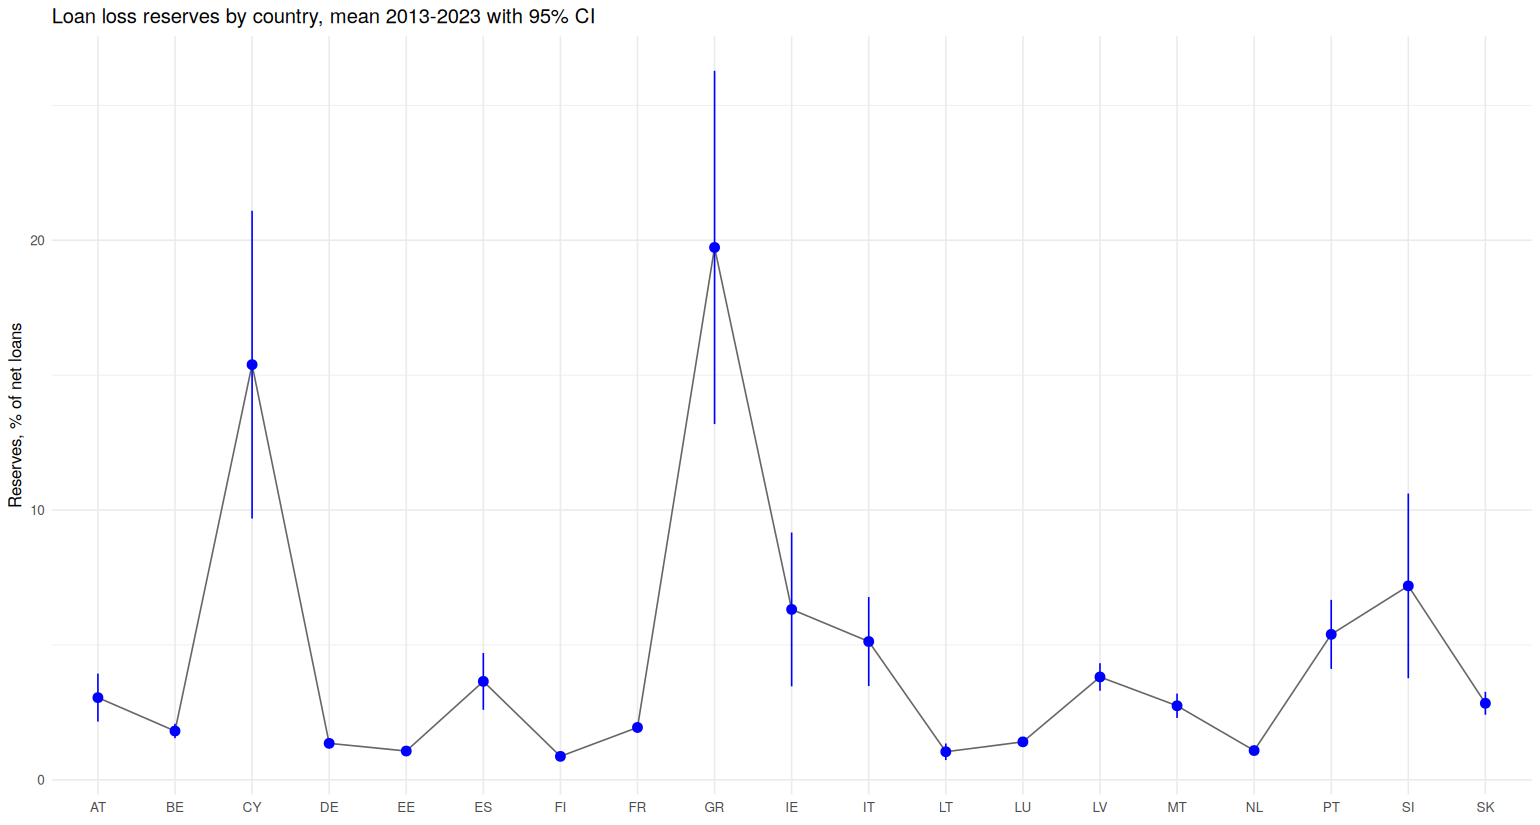

In [25]:
if (BANKFOCUS_AVAILABLE) means_chart(credit_risk, "llr_ratio", "country", "Loan loss reserves by country, mean 2013-2023 with 95% CI", "Reserves, % of net loans")

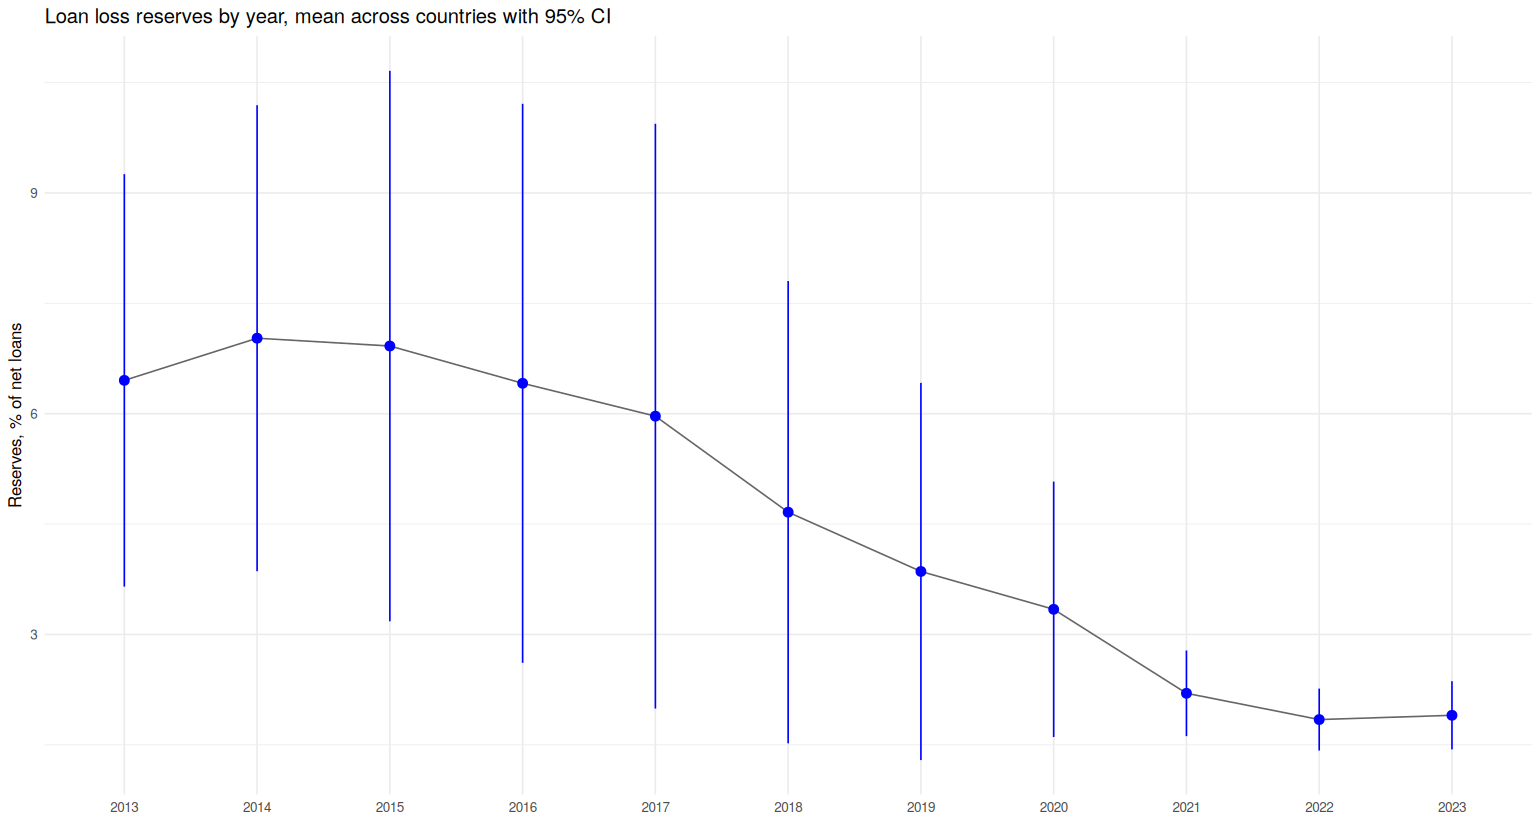

In [26]:
if (BANKFOCUS_AVAILABLE) means_chart(credit_risk, "llr_ratio", "year", "Loan loss reserves by year, mean across countries with 95% CI", "Reserves, % of net loans")

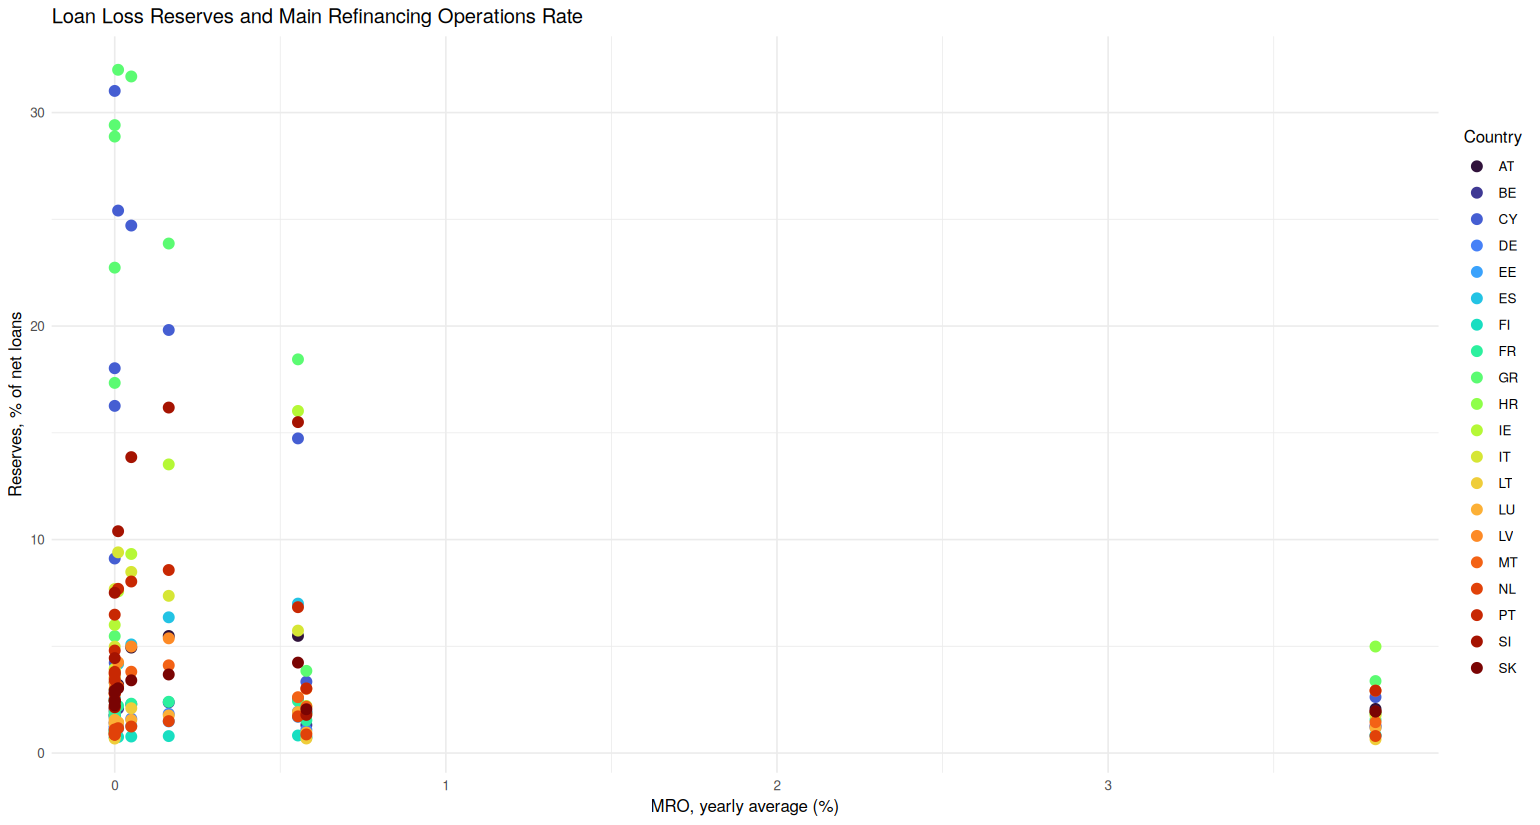

In [27]:
if (BANKFOCUS_AVAILABLE) credit_risk_chart("llr_ratio", "Loan Loss Reserves and Main Refinancing Operations Rate", "Reserves, % of net loans")

### Regressions

Each variable on the MRO with country fixed effects. Loan growth, NIM and the ratios are in %,
so each coefficient is the change in percentage points associated with a 1 point higher MRO.

In [28]:
if (BANKFOCUS_AVAILABLE) {
  # One model per variable; yearly panels, so Driscoll-Kraay with 2 lags
  balance_sheet_specs <- list(
    model_spec(loan_growth, loan_growth ~ MRO, c("country", "year"), "Loan growth", 2),
    model_spec(nim, nim ~ MRO, c("country", "year"), "Net interest margin", 2),
    model_spec(credit_risk, npl_ratio ~ MRO, c("country", "year"), "NPL ratio", 2),
    model_spec(credit_risk, llr_ratio ~ MRO, c("country", "year"), "Loan loss reserves ratio", 2)
  )
  balance_sheet_models <- map_dfr(balance_sheet_specs, fe_regression)   # one row per model
  balance_sheet_models %>% mutate(across(where(is.double), ~ signif(.x, 3)))
}

model,MRO_coefficient,std_error,p_value,std_error_clustered,p_value_clustered,std_error_dk,p_value_dk,r2_within,countries,observations
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
Loan growth,2.180,0.3920,5.97e-08,0.4370,1.03e-06,0.9880,2.78e-02,0.0981,19,305
Net interest margin,0.146,0.0136,1.06e-22,0.0231,9.81e-10,0.0379,1.46e-04,0.2830,19,309
NPL ratio,-1.650,0.4620,4.48e-04,0.6620,1.35e-02,0.3920,3.93e-05,0.0643,20,207
Loan loss reserves ratio,-0.847,0.2480,7.65e-04,0.3350,1.24e-02,0.2240,2.11e-04,0.0592,20,207


## Diagnostic tests

Four checks on every model, all from the `plm` package. A small p-value rejects the null
hypothesis.

| Test | Null hypothesis | If rejected |
|---|---|---|
| F test for country effects (`pFtest`) | no country effects: pooled OLS is enough | country fixed effects are needed |
| Breusch-Godfrey/Wooldridge (`pbgtest`, order 1) | no serial correlation in the residuals | usual standard errors are too small |
| Pesaran CD (`pcdtest`) | residuals independent across countries | clustering by country is not enough |
| Hausman (`phtest`) | random effects are consistent | random effects are biased, fixed effects preferred |

The Hausman test is reported with the random-effects coefficient next to the fixed-effects one.
Here it has little power: the MRO is the same for every country, so it cannot be correlated with
the country effects, and the fixed- and random-effects estimates are almost identical by
construction. Fixed effects are kept in every model: with 18–20 countries that are the whole
population of interest rather than a sample, they are the natural choice, and they cost little.

In [29]:
# fe_diagnostics(spec)
# Estimates the same model three ways (fixed effects, random effects, pooled OLS) and returns
# one row with the p-values of the four tests and the MRO coefficient under fixed and random
# effects, so that the size of any difference can be seen next to the Hausman p-value.
fe_diagnostics <- function(spec) {
  pd <- pdata.frame(spec$data, index = spec$index)
  fe <- plm(spec$formula, data = pd, model = "within")      # country fixed effects
  re <- plm(spec$formula, data = pd, model = "random")      # country random effects
  pooled <- plm(spec$formula, data = pd, model = "pooling") # one OLS on all observations
  tibble(model = spec$label,
         # F test: fixed effects against pooled OLS (H0: all country effects equal)
         F_country_effects_p = pFtest(fe, pooled)$p.value,
         # Breusch-Godfrey/Wooldridge: H0 no first-order serial correlation of the residuals
         serial_correlation_p = pbgtest(fe, order = 1)$p.value,
         # Pesaran CD: H0 residuals uncorrelated across countries.
         # Countries that joined the euro late share few years with some others: those pairs
         # are left out of the statistic (plm warns about it)
         cross_section_dependence_p = suppressWarnings(pcdtest(fe, test = "cd"))$p.value,
         # Hausman: H0 random effects consistent (no systematic difference from FE)
         hausman_p = phtest(fe, re)$p.value,
         MRO_fixed_effects = coef(fe)[["MRO"]],
         MRO_random_effects = coef(re)[["MRO"]])
}

# All models: the three pass-through models and, if the BankFocus files are available,
# the four balance-sheet models
all_specs <- c(rate_specs, if (BANKFOCUS_AVAILABLE) balance_sheet_specs)
diagnostics <- map_dfr(all_specs, fe_diagnostics)
diagnostics %>% mutate(across(where(is.double), ~ signif(.x, 3)))

model,F_country_effects_p,serial_correlation_p,cross_section_dependence_p,hausman_p,MRO_fixed_effects,MRO_random_effects
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"Lending rate, Consumption",0.00e+00,0.00e+00,5.15e-164,6.44e-01,0.306,0.305
"Lending rate, Mortgages",5.72e-233,0.00e+00,0.00e+00,5.79e-06,0.569,0.569
"Lending rate, Corporations",0.00e+00,0.00e+00,0.00e+00,1.97e-01,0.659,0.659
Loan growth,2.13e-03,6.40e-04,2.55e-41,1.30e-06,2.180,1.920
Net interest margin,1.70e-84,5.16e-09,6.18e-14,8.47e-01,0.146,0.145
NPL ratio,5.29e-37,1.34e-30,9.70e-130,8.83e-01,-1.650,-1.640
Loan loss reserves ratio,4.16e-32,1.94e-28,6.79e-115,6.50e-01,-0.847,-0.831


**Reading the tests.**

- **Country effects are needed** in every model: pooled OLS would mix the differences in
  levels across countries (Greek or Portuguese banks have structurally higher rates and NPLs)
  with the effect of the MRO.
- **Residuals are autocorrelated and correlated across countries.** Lending rates, margins and
  credit quality move slowly, and the whole euro area is hit by the same shocks (the financial
  crisis, the sovereign debt crisis, the pandemic, the 2022 inflation). The usual standard errors
  are therefore too small, and clustering by country corrects only for the first problem.
- **Driscoll-Kraay standard errors** are robust to both, and are the reference for inference.
  With them the pass-through to lending rates, the NIM and the credit-risk coefficients remain
  clearly significant; the loan growth coefficient is the weakest result.
- **Hausman.** It does not reject for five models out of seven. It rejects for mortgage rates,
  where the two coefficients are identical to the third decimal and the rejection only reflects
  the almost 4,000 observations, and for loan growth, where the random-effects coefficient is
  somewhat smaller (1.9 against 2.2). In both cases fixed effects remain the right choice.

In [30]:
# Main results table: coefficient with Driscoll-Kraay standard errors
regressions <- bind_rows(pass_through, if (BANKFOCUS_AVAILABLE) balance_sheet_models)
regressions %>%
  transmute(model, MRO_coefficient, std_error_dk, p_value_dk, r2_within, countries,
            observations) %>%
  mutate(across(where(is.double), ~ signif(.x, 3)))

model,MRO_coefficient,std_error_dk,p_value_dk,r2_within,countries,observations
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
"Lending rate, Consumption",0.306,0.0663,4.16e-06,0.1240,18,3558
"Lending rate, Mortgages",0.569,0.0723,4.43e-15,0.6060,19,3888
"Lending rate, Corporations",0.659,0.0728,2.20e-19,0.6820,19,3888
Loan growth,2.180,0.9880,2.78e-02,0.0981,19,305
Net interest margin,0.146,0.0379,1.46e-04,0.2830,19,309
NPL ratio,-1.650,0.3920,3.93e-05,0.0643,20,207
Loan loss reserves ratio,-0.847,0.2240,2.11e-04,0.0592,20,207


## Saving the results

In [31]:
dir.create(OUT_DIR, showWarnings = FALSE)
write_csv(regressions, file.path(OUT_DIR, "cs3_regressions.csv"))    # all standard errors
write_csv(diagnostics, file.path(OUT_DIR, "cs3_diagnostics.csv"))    # test p-values
write_csv(select(rate_panel, -date), file.path(OUT_DIR, "cs3_rate_panel.csv"))  # public data
if (BANKFOCUS_AVAILABLE) {
  # Country aggregates only (at least 3 banks each)
  write_csv(loan_growth, file.path(OUT_DIR, "cs3_loan_growth.csv"))
  write_csv(nim, file.path(OUT_DIR, "cs3_nim.csv"))
  write_csv(credit_risk, file.path(OUT_DIR, "cs3_credit_risk.csv"))
}
list.files(OUT_DIR)

[1] "cs3_credit_risk.csv" "cs3_diagnostics.csv" "cs3_loan_growth.csv"
[4] "cs3_nim.csv"         "cs3_rate_panel.csv"  "cs3_regressions.csv"